# Temporary Explorative Data Analyse

## Charger les données


In [27]:
import pandas as pd
import numpy as np
import glob

In [28]:
df_linkedin = pd.read_excel('scraping_results/result_linkedin.com.xlsx')
df_linkedin.head()

,config_name,domain,country,currency,date,brand,start_url,start_url_formatted,url,entreprise,poste,description,date_de_publication,nb_candidats,location
0,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4386503400/...,RSM France,Consultant Senior Data & IA H/F (75),Rejoignez RSM et participez à une aventure hum...,Republication il y a 2 semaines,26 personnes ont cliqué sur Postuler,"Paris, Île-de-France, France"
1,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4390938905/...,Capgemini Invent Giulia Arca,Consultante expérimentée / Consultant expérime...,Consultante expérimentée / Consultant expérime...,Republication il y a 2 semaines,64 candidats,"Issy-les-Moulineaux, Île-de-France, France"
2,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4392431203/...,GEC _ Global Experts Consulting,Consultant ServiceNow Technico-Fonctionnel – I...,Dans le cadre du déploiement de cas d’usage d’...,il y a 3 semaines,14 candidats,"Paris, Île-de-France, France"
3,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4389275158/...,Talan,Consulting - Consultant Confirmé / Senior – St...,"Description de l'entreprise Fondé en France, T...",il y a 1 mois,4 personnes ont cliqué sur Postuler,"Paris, Île-de-France, France"
4,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4402502434/...,Sia,Consultant(e) Senior Data Science & IA,Sia est un groupe international de conseil en ...,il y a 1 semaine,19 candidats,"Paris, Île-de-France, France"


In [29]:
fichiers_xlsx = glob.glob("scraping_results/*.xlsx")

liste_dataframes = []


for fichier in fichiers_xlsx:
  df_temp = pd.read_excel(fichier)
  
  df_temp = df_temp.rename(columns={'profil_recherche':'experience', 'brand': 'poste_recherche'})

  liste_dataframes.append(df_temp)
  
df_global = pd.concat(liste_dataframes, ignore_index=True)

# Dropping useless data columns
df_global = df_global.drop(columns = ["config_name","currency",
                                      "start_url","start_url_formatted",
                                      "country", "poste_recherche"])

df_global["date"] = pd.to_datetime(df_global["date"]).dt.strftime("%Y-%m")

before = len(df_global)
df_global = df_global.drop_duplicates()
print("Nombre de doublons supprimé : ", before - len(df_global))

df_global.head()

Nombre de doublons supprimé :  0


,domain,date,url,entreprise,poste,description,date_de_publication,nb_candidats,location,experience
0,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4386503400/...,RSM France,Consultant Senior Data & IA H/F (75),Rejoignez RSM et participez à une aventure hum...,Republication il y a 2 semaines,26 personnes ont cliqué sur Postuler,"Paris, Île-de-France, France",NaN
1,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4390938905/...,Capgemini Invent Giulia Arca,Consultante expérimentée / Consultant expérime...,Consultante expérimentée / Consultant expérime...,Republication il y a 2 semaines,64 candidats,"Issy-les-Moulineaux, Île-de-France, France",NaN
2,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4392431203/...,GEC _ Global Experts Consulting,Consultant ServiceNow Technico-Fonctionnel – I...,Dans le cadre du déploiement de cas d’usage d’...,il y a 3 semaines,14 candidats,"Paris, Île-de-France, France",NaN
3,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4389275158/...,Talan,Consulting - Consultant Confirmé / Senior – St...,"Description de l'entreprise Fondé en France, T...",il y a 1 mois,4 personnes ont cliqué sur Postuler,"Paris, Île-de-France, France",NaN
4,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4402502434/...,Sia,Consultant(e) Senior Data Science & IA,Sia est un groupe international de conseil en ...,il y a 1 semaine,19 candidats,"Paris, Île-de-France, France",NaN


In [30]:
df = df_global.copy()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2472 entries, 0 to 2471
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   domain               2472 non-null   str  
 1   date                 2472 non-null   str  
 2   url                  2469 non-null   str  
 3   entreprise           2175 non-null   str  
 4   poste                2457 non-null   str  
 5   description          2455 non-null   str  
 6   date_de_publication  1317 non-null   str  
 7   nb_candidats         792 non-null    str  
 8   location             2343 non-null   str  
 9   experience           729 non-null    str  
dtypes: str(10)
memory usage: 193.3 KB


In [31]:
df.value_counts('domain')

domain
linkedin.com                 1105
fr.indeed.com                 564
candidat.francetravail.fr     376
hellowork.com                 345
jobs.stationf.co               82
Name: count, dtype: int64

In [32]:
df.iloc[0]["description"]

"Rejoignez RSM et participez à une aventure humaine et entrepreneuriale ! Mission RSM est devenu 6ème réseau mondial en Audit, Expertise Comptable et Conseil grâce à l’engagement de nos équipes. Dans notre bureau de Paris, plus de 600 expert∙e∙s évoluent au quotidien dans un environnement bienveillant et en constante évolution, où autonomie et prise d’initiatives sont valorisées. « Lors de mon arrivée, ce qui m’a tout de suite plu c’est la relation humaine et la proximité avec les associés. Les équipes grandissent, pour autant la gestion reste à taille humaine. » Antoine « Chez RSM toutes les conditions sont réunies pour progresser et aller de l’avant, c’est vraiment une très bonne école de formation. » Richard Chez RSM, chaque jour est une opportunité de grandir. Nous avons à cœur de faire évoluer nos collaborateur∙trice∙s tout en accompagnant nos clients avec excellence. Ainsi, 95% des collaborateurs nous recommandent. Si vous êtes passionné∙e, ambitieux∙se et prêt∙e à rejoindre une 

In [33]:
# Get indexes where experience is not null
exp_indices = df[df["experience"].notna()].index

exp_indices = np.random.permutation(exp_indices)

print(f"Offers with experience field extracted : {len(exp_indices)}")

Offers with experience field extracted : 729


In [34]:
counts = df["poste"].value_counts()

counts.to_csv('titre_des_postes.csv')

In [35]:
print(f'Il y a {len(counts)} titre de poste unique')

Il y a 1676 titre de poste unique


In [36]:
import re, unicodedata
import pandas as pd

def norm(s):
    # NFKD : retire les accents et convertit les caractères "gras" Unicode
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c)).lower()

# --- Briques réutilisables ---
DATA = (r"data|donnee|\bia\b|\bai\b|\bbi\b|analytics|power ?bi|talend|dataiku|teradata|"
        r"snowflake|machine learning|\bml\b|genai|llm")
ENG  = r"engineer|ingenieur|developpeu|research|scientist|\bops\b|mlops"

# --- Règles, par ordre de priorité ---
RULES = [
    # 1. Consultant : prioritaire, à condition d'avoir un mot data/IA/ML dans le titre
    ("Consultant Data / IA",
     lambda t: re.search(r"consult|conseil", t) and re.search(DATA, t)),

    # 2. Data Science
    ("Data Science",
     lambda t: re.search(r"data ?scien|datascien|statisticien", t)),

    # 3. Data Engineer (sans BI)
    ("Data Engineer",
     lambda t: re.search(
         r"data engineer|data ingenieur|ingenieur (de )?(donnees|data)|big data|analytics engineer|"
         r"data platform|databricks|snowflake|dataops|\betl\b|data architect|architecte data|"
         r"developpeu\w* (data|talend|databricks)", t)),

    # 4. ML / IA Engineer (il faut un mot "engineer/ingénieur/..." pour éviter AI Trainer, AI Product Manager...)
    ("ML / IA Engineer",
     lambda t: re.search(
         r"machine learning|\bml\b|mlops|ml ops|\bai\b|\bia\b|genai|llm|intelligence artificielle|"
         r"agentic|agentique|deep learning|computer vision", t) and re.search(ENG, t)),

    # 5. Data Analyst / BI (couvre aussi "BI Engineer", "Ingénieur BI", "Développeur BI")
    ("Data Analyst",
     lambda t: re.search(
         r"data.*analy|analy.*(data|donnees)|power ?bi|\bbi\b|business intelligence|web ?analy|reporting", t)),
]

def categorize(titre):
    t = norm(titre)
    for label, test in RULES:
        if test(t):
            return label
    return "Autre"

# --- Application ---
counts = df["poste"].value_counts().rename_axis("poste").reset_index(name="n")
counts["cat_regex"] = counts["poste"].apply(categorize)

print(counts.groupby("cat_regex")["n"].sum().sort_values(ascending=False))


cat_regex
Autre                   548
Data Analyst            510
Consultant Data / IA    395
Data Engineer           393
Data Science            330
ML / IA Engineer        281
Name: n, dtype: int64


## Data Processing 

### Get the seniority levels

#### Test 

In [37]:
import copy
import json
from pathlib import Path

import ollama
import pandas as pd
from tqdm import tqdm


# ---------------------------------------------------------------------------
# Catégories et missions types
# ---------------------------------------------------------------------------

MODEL = "qwen3:14b"

CATEGORIES = {
    "Data Analyst": "DA",
    "Consultant Data / IA": "CONSULTANT",
    "Data Engineer": "DE",
    "Data Scientist": "DS",
    "ML / IA Engineer": "MLE",
    "Autre": "AUTRE",
}
CATEGORY_NAMES = list(CATEGORIES)


MISSIONS_DA = [
    "Traduire un besoin métier en question d’analyse",
    "Extraire et combiner des données",
    "Interroger des bases de données",
    "Nettoyer et préparer des données",
    "Explorer un jeu de données",
    "Réaliser des analyses statistiques descriptives",
    "Définir et calculer des indicateurs",
    "Modéliser des données pour l’analyse",
    "Créer des tableaux de bord",
    "Visualiser des données",
    "Analyser des tendances et des écarts",
    "Segmenter des données",
    "Rechercher les causes d’un problème à partir des données",
    "Réaliser des tests statistiques",
    "Concevoir ou analyser des tests A/B",
    "Produire des prévisions simples",
    "Contrôler la qualité des données",
    "Automatiser des analyses et des rapports",
    "Interpréter et restituer des résultats",
    "Documenter les indicateurs et les règles de calcul",
]

MISSIONS_CONSULTANT = [
    "Recueillir et formaliser les besoins liés aux données",
    "Diagnostiquer la maturité data d’une organisation",
    "Traduire un problème métier en problème data ou IA",
    "Identifier des cas d’usage data et IA",
    "Prioriser les cas d’usage selon leur valeur et leur faisabilité",
    "Évaluer la disponibilité et la qualité des données",
    "Définir une stratégie data ou IA",
    "Définir une feuille de route data",
    "Concevoir une architecture de données cible",
    "Concevoir une solution d’analyse ou d’IA",
    "Rédiger des spécifications fonctionnelles et techniques",
    "Définir des règles de gouvernance des données",
    "Définir des contrôles de qualité des données",
    "Évaluer des solutions et plateformes data",
    "Concevoir et cadrer une preuve de concept",
    "Intégrer une solution data ou IA dans un système existant",
    "Cadrer et suivre la mise en œuvre d’un projet data",
    "Évaluer la conformité et les risques liés aux données et à l’IA",
    "Évaluer les performances d’une solution data ou IA",
    "Mesurer la valeur produite par une solution data ou IA",
]

MISSIONS_DE = [
    "Collecter des données depuis différentes sources",
    "Ingérer des données en traitement par lots",
    "Ingérer des données en flux continu",
    "Concevoir des traitements ETL ou ELT",
    "Transformer et structurer des données",
    "Concevoir des pipelines de données",
    "Orchestrer des traitements de données",
    "Concevoir des modèles pour entrepôts de données",
    "Concevoir des architectures lakehouse ou data lake",
    "Traiter des données distribuées à grande échelle",
    "Optimiser des requêtes et traitements de données",
    "Développer des solutions de traitement de données",
    "Intégrer des API et des sources de données",
    "Tester des pipelines et traitements",
    "Contrôler la qualité des données",
    "Gérer les métadonnées, la traçabilité et la lignée des données",
    "Sécuriser les accès aux données",
    "Déployer et surveiller des pipelines",
    "Diagnostiquer les incidents de traitement de données",
    "Optimiser la performance et le coût des traitements",
]

MISSIONS_DS = [
    "Transformer un problème métier ou scientifique en problème d’analyse",
    "Collecter et préparer des données pour la modélisation",
    "Explorer des jeux de données",
    "Appliquer des méthodes statistiques et probabilistes",
    "Construire des variables explicatives",
    "Entraîner des modèles de classification",
    "Entraîner des modèles de régression",
    "Réaliser des analyses de clustering",
    "Construire des modèles de séries temporelles",
    "Concevoir des expériences et tests",
    "Réaliser des analyses causales",
    "Analyser des données textuelles",
    "Analyser des images ou des données visuelles",
    "Construire des systèmes de recommandation ou de classement",
    "Sélectionner et entraîner des modèles",
    "Évaluer et valider des modèles",
    "Interpréter les résultats d’un modèle",
    "Quantifier l’incertitude des prédictions",
    "Présenter des résultats et recommandations fondés sur les données",
    "Évaluer les biais et limites d’une analyse ou d’un modèle",
]

MISSIONS_MLE = [
    "Concevoir l’architecture d’un système de machine learning ou d’IA",
    "Préparer les données pour l’entraînement et l’inférence",
    "Construire des pipelines de données et de variables pour les modèles",
    "Entraîner ou affiner des modèles",
    "Suivre les expériences et les versions de modèles",
    "Évaluer la qualité des modèles",
    "Déployer des modèles en production",
    "Exposer des modèles via des API",
    "Intégrer des modèles dans des applications",
    "Automatiser l’entraînement et le déploiement des modèles",
    "Surveiller les performances et la dérive des modèles",
    "Optimiser la latence, le débit et le coût d’inférence",
    "Adapter les modèles à une exécution distribuée ou à grande échelle",
    "Mettre en œuvre des systèmes de recherche sémantique",
    "Concevoir des applications fondées sur la génération augmentée par recherche",
    "Concevoir et évaluer des instructions pour des modèles génératifs",
    "Tester la qualité et la sécurité des systèmes d’IA générative",
    "Mettre en place des garde-fous pour les systèmes d’IA",
    "Assurer la reproductibilité et les tests des systèmes de modèles",
    "Gérer le cycle de vie des modèles en production",
]


def _bullets(missions: list) -> str:
    """Formate une mission par ligne."""
    return "\n".join(f"- {mission}" for mission in missions)


# ---------------------------------------------------------------------------
# Prompt v5
# f-string : {_bullets(...)} est remplacé par la liste.
# Ne mets pas d'accolades littérales dans le texte du prompt.
# ---------------------------------------------------------------------------

SYSTEM_JOB_SKILLS_V5 = f"""Tu es un analyste du marché de l'emploi data en France. Tu reçois une offre sous la forme de trois champs : Title, Raw experience et Description. Raw experience contient le profil et les prérequis éventuels. Description peut contenir les missions, le profil et les prérequis. Un champ peut valoir "not provided".

Extrais les missions et compétences de l'offre, puis classe-la dans une catégorie principale et, si nécessaire, une catégorie alternative.

## Catégories

Data Analyst : transforme des données en indicateurs, analyses et tableaux de bord pour répondre à des questions métier.
Missions types :
{_bullets(MISSIONS_DA)}

Consultant Data / IA : cadre, conçoit et pilote des projets data ou IA (besoins, stratégie, gouvernance, architecture cible, cas d'usage), sans être le principal développeur.
Missions types :
{_bullets(MISSIONS_CONSULTANT)}

Data Engineer : construit et exploite l'infrastructure et les pipelines qui collectent, transforment et mettent à disposition les données.
Missions types :
{_bullets(MISSIONS_DE)}

Data Scientist : modélise, expérimente et valide des modèles statistiques et de machine learning pour résoudre un problème.
Missions types :
{_bullets(MISSIONS_DS)}

ML / IA Engineer : construit, intègre, industrialise ou déploie des modèles et systèmes d'IA en production (MLOps, API, inférence, IA générative, agents, RAG).
Missions types :
{_bullets(MISSIONS_MLE)}

Autre : les responsabilités principales ne relèvent pas d'un métier data ou IA, par exemple développement logiciel généraliste, cybersécurité, DevOps, infrastructure, réseau, QA ou fonction commerciale.

## Règles de classement

Prends en compte le titre original, les missions et le profil recherché. Le titre est un indice important sur le métier visé. Vérifie cette indication à partir du travail réellement demandé.

1. Analyse les tâches confiées à la personne recrutée. Écarte les présentations générales de l'entreprise, de ses produits, de sa culture ou de son secteur.

2. Si le titre nomme clairement un métier et que les missions sont vagues ou génériques, choisis la catégorie indiquée par le titre.

3. Si le titre nomme clairement un métier et que les missions décrivent clairement un autre métier, choisis la catégorie correspondant aux responsabilités réelles et explique brièvement cet écart.

4. Si le titre et les missions indiquent plusieurs métiers proches, identifie d'abord les catégories plausibles à partir des missions. Choisis celle qui correspond au livrable et à la responsabilité principaux. Utilise le titre pour départager les catégories plausibles.

5. Si le titre contient plusieurs métiers, par exemple « Data Analyst / Data Consultant », compare chaque option aux missions. Ne choisis pas une catégorie uniquement parce que son terme apparaît dans le titre.

6. Ne te base pas sur une catégorie produite par un regex ou un autre système.

### Règle de promotion de la catégorie alternative par le titre

Après avoir déterminé la catégorie principale et une catégorie alternative plausible à partir des missions et du profil, examine le titre original.

Si le titre nomme explicitement le métier correspondant à la catégorie alternative, et que les missions ne contredisent pas clairement cette catégorie, inverse les deux catégories dans la sortie :
- la catégorie alternative devient la catégorie principale ;
- l'ancienne catégorie principale devient la catégorie alternative.

Applique cette inversion uniquement si la catégorie alternative était déjà plausible d'après les missions ou le profil. Un mot simplement proche, une mention générique ou le nom d'un outil ne suffit pas.

Exemples de titres qui nomment explicitement un métier :
- « Data Analyst », « Analyste de données », « Business Analyst Data » : Data Analyst ;
- « Data Engineer », « Ingénieur Data », « Analytics Engineer » : Data Engineer ;
- « Data Scientist » : Data Scientist ;
- « AI Engineer », « ML Engineer », « Machine Learning Engineer », « MLOps Engineer » : ML / IA Engineer ;
- « Data Consultant », « Consultant Data » : Consultant Data / IA.

Les mots « Data », « IA », « Analyst », « Consultant », « Engineer » ou « Manager » pris seuls ne déclenchent pas l'inversion.

Si les missions sont vagues ou génériques, le titre explicite peut directement déterminer la catégorie principale. Si le titre est vague, comme « On recrute ! », classe surtout à partir des missions et du profil.

### Distinguer Data Analyst et Consultant Data / IA

- Choisis Data Analyst lorsque le cœur du poste est d'analyser des données, définir ou suivre des indicateurs, produire des analyses, tableaux de bord ou reportings pour répondre aux besoins métier.
- Cela reste Data Analyst même si le poste est chez un cabinet de conseil, implique des échanges avec des clients ou porte le mot « Consultant » dans le titre.
- Choisis Consultant Data / IA lorsque le cœur du poste est de cadrer des besoins, définir une stratégie ou une feuille de route, établir la gouvernance ou l'architecture cible, prioriser des cas d'usage, ou piloter la transformation et les projets data ou IA.
- Le fait de travailler dans une société de conseil, chez un client, d'animer des ateliers ou de collaborer avec des équipes métier ne suffit pas à justifier Consultant Data / IA.
- La production d'analyses, de tableaux de bord ou de pipelines ne suffit pas à justifier Consultant Data / IA.

### Distinguer Data Scientist et ML / IA Engineer

- Choisis Data Scientist lorsque le cœur du poste est de formuler des problèmes analytiques ou scientifiques, concevoir et expérimenter des modèles statistiques ou de machine learning, puis évaluer et valider leurs résultats.
- L'utilisation de Python ou la réalisation d'analyses de données, à elles seules, ne suffit pas à justifier Data Scientist.
- Choisis ML / IA Engineer lorsque le cœur du poste est de construire, intégrer, évaluer, industrialiser ou déployer des systèmes d'IA : modèles, LLM, agents, RAG, API ou applications IA.
- L'entraînement d'un modèle n'est pas obligatoire pour choisir ML / IA Engineer.
- Un titre explicite comme « AI Engineer », « ML Engineer » ou « Machine Learning Engineer » est un indice fort si les missions sont vagues ou compatibles avec ce rôle.
- Choisis Autre si l'IA n'apparaît que dans le contexte de l'entreprise ou du produit, sans tâche concrète liée à l'IA, et que le travail demandé relève d'un autre métier.
- Un poste surtout consacré à la prospection et à la vente de solutions IA relève d'Autre si la personne ne cadre pas, ne conçoit pas et ne met pas en œuvre ces solutions.

### Autres repères

- « Data Engineer », « Ingénieur Data », « Analytics Engineer » : généralement Data Engineer si le travail porte sur les flux, transformations ou pipelines.
- « Data Steward », gouvernance Data, chef de projet Data : généralement Consultant Data / IA si le travail porte sur la gouvernance, le cadrage ou le pilotage.
- « BI Developer » ou un titre centré sur le reporting : généralement Data Analyst si le travail porte sur les analyses, indicateurs et tableaux de bord.
- « Data Architect » : Consultant Data / IA pour le cadrage et la conception ; Data Engineer pour la mise en œuvre technique.

Ces repères sont des indices, pas des règles automatiques.

Choisis Autre lorsque le travail demandé ne relève principalement d'aucune des cinq catégories Data / IA. Une mention de « Data » ou d'« IA » dans le titre ne suffit pas à elle seule à classer l'offre dans une catégorie data.

Renseigne une catégorie alternative uniquement si le poste combine réellement deux métiers ou si les missions permettent raisonnablement deux classements. Si aucune autre catégorie n'est plausible, renseigne « Aucune ».

## Missions relevées

- Renseigne de 3 à 6 missions principales, brièvement reformulées à partir de l'offre.
- Ne reprends que les responsabilités réellement décrites.
- N'invente pas de missions si la description est insuffisante.

## Extraction des compétences

- Extrais les compétences présentes dans l'offre. N'ajoute pas d'outils parce qu'ils sont courants dans le métier.
- Analyse Description et Raw experience : les missions et les prérequis peuvent apparaître dans l'un ou l'autre champ.
- stack_requise contient les langages, outils, bibliothèques, frameworks, plateformes et bases de données nommés dans les missions ou présentés comme requis ou attendus dans le profil.
- stack_souhaitee contient les technologies explicitement présentées comme facultatives : « apprécié », « serait un atout », « idéalement », « nice to have », « un plus » ou formulation équivalente.
- Une technologie ne doit apparaître que dans une seule liste. En cas de doute sur son caractère facultatif, classe-la dans stack_requise.
- Normalise les noms et supprime les doublons : « scikit-learn », « Power BI », « PyTorch », « PostgreSQL », « JavaScript », « Google Cloud Platform ».
- Si l'offre présente des technologies comme des alternatives exclusives, rassemble-les dans une seule chaîne séparée par |, par exemple « Python|Java ». Si plusieurs technologies sont demandées, garde une entrée par technologie.
- N'ajoute pas un outil absent du texte, même s'il est couramment associé à un outil cité.
- Exclue de la stack les soft skills, les méthodes (Agile, Scrum), les notions générales (machine learning, statistiques, NLP, deep learning, data viz, ETL), les domaines métier, les diplômes et les niveaux d'expérience.
- competences_requises contient les savoir-faire et connaissances non liés à un outil qui sont explicitement exigés ou directement nécessaires aux missions décrites.
- competences_souhaitees contient les savoir-faire et connaissances non liés à un outil explicitement présentés comme facultatifs.
- N'infère pas une compétence à partir de ce qui est simplement typique du métier. Une mission décrite peut révéler le savoir-faire correspondant, mais n'en déduis pas des outils non cités.
- N'inclus pas les soft skills dans ces listes de compétences techniques.
- Si une liste est vide, renvoie une liste vide.

## Justification

Rédige une phrase courte expliquant le classement à partir du titre original, des missions et du profil. Si le titre et les missions divergent, précise quel élément a déterminé la catégorie principale. Si le titre a conduit à promouvoir la catégorie alternative, indique que le titre a départagé deux catégories compatibles avec les missions.

## Sortie

Réponds uniquement avec un JSON strict, sans commentaire ni texte avant ou après.
Le JSON doit contenir exactement les champs suivants :
missions_relevees, stack_requise, stack_souhaitee, competences_requises, competences_souhaitees, justification, categorie, categorie_alternative.

Utilise exactement l'un de ces noms de catégorie :
Data Analyst, Consultant Data / IA, Data Engineer, Data Scientist, ML / IA Engineer, Autre.

Si aucune catégorie alternative n'est réellement plausible, renseigne « Aucune ».
"""


# ---------------------------------------------------------------------------
# Schéma JSON de la v5
# ---------------------------------------------------------------------------

_STR_LIST = {
    "type": "array",
    "items": {"type": "string"},
}

SCHEMA_JOB_SKILLS_V5 = {
    "type": "object",
    "properties": {
        "missions_relevees": _STR_LIST,
        "stack_requise": _STR_LIST,
        "stack_souhaitee": _STR_LIST,
        "competences_requises": _STR_LIST,
        "competences_souhaitees": _STR_LIST,
        "justification": {"type": "string"},
        "categorie": {
            "type": "string",
            "enum": CATEGORY_NAMES,
        },
        "categorie_alternative": {
            "type": "string",
            "enum": CATEGORY_NAMES + ["Aucune"],
        },
    },
    "required": [
        "missions_relevees",
        "stack_requise",
        "stack_souhaitee",
        "competences_requises",
        "competences_souhaitees",
        "justification",
        "categorie",
        "categorie_alternative",
    ],
}


# ---------------------------------------------------------------------------
# Sauvegarde du prompt dans instructions_llm.json
# ---------------------------------------------------------------------------

path = Path("src/extraction/instructions_llm.json")

with path.open(encoding="utf-8") as file:
    config = json.load(file)

# Accepte les deux noms de clé utilisés dans tes extraits précédents.
if "job_classifier_prompt" in config:
    prompt_key = "job_classifier_prompt"
elif "job_classifier" in config:
    prompt_key = "job_classifier"
else:
    prompt_key = "job_classifier_prompt"
    config[prompt_key] = {}

prompt_config = config[prompt_key]

prompt_config["v5"] = {
    "model": MODEL,
    "params": {
        "temperature": 0,
        "num_ctx": 12000,
    },
    "notes": (
        "Le titre original est pris en compte avec les missions. "
        "Si le titre nomme explicitement une catégorie alternative plausible, "
        "le modèle inverse les catégories sauf contradiction claire des missions."
    ),
    "system_prompt": SYSTEM_JOB_SKILLS_V5,
    "schema": SCHEMA_JOB_SKILLS_V5,
}
prompt_config["active_version"] = "v5"

with path.open("w", encoding="utf-8") as file:
    json.dump(config, file, ensure_ascii=False, indent=2)

prompt_cfg = prompt_config["v5"]


# ---------------------------------------------------------------------------
# Classification par LLM local
# ---------------------------------------------------------------------------

def _val(value) -> str:
    if pd.isna(value):
        return "not provided"
    return str(value)


def classify_llm(row, prompt_cfg, mask_title=False) -> dict:
    title = "not provided" if mask_title else _val(row["poste"])

    user_prompt = (
        f"Title: {title}\n"
        f"Raw experience: {_val(row['experience'])}\n"
        f"Description:\n{_val(row['description'])}"
    )

    try:
        response = ollama.chat(
            model=prompt_cfg["model"],
            messages=[
                {"role": "system", "content": prompt_cfg["system_prompt"]},
                {"role": "user", "content": user_prompt},
            ],
            format=prompt_cfg["schema"],
            options=prompt_cfg.get(
                "params",
                {"temperature": 0, "num_ctx": 12000},
            ),
            think=False,
            keep_alive="30m",
        )

        data = json.loads(response.message.content)
        data["categorie_code"] = CATEGORIES[data["categorie"]]
        return data

    except Exception as error:
        return {
            "categorie": None,
            "erreur": str(error),
        }


def run(df: pd.DataFrame, prompt_cfg, mask_title=False) -> pd.DataFrame:
    results = [
        classify_llm(row, prompt_cfg, mask_title=mask_title)
        for _, row in tqdm(df.iterrows(), total=len(df))
    ]

    return pd.concat(
        [df.reset_index(drop=True), pd.DataFrame(results)],
        axis=1,
    )


# Exemple d'exécution avec le titre original :
# res_v5 = run(df, prompt_cfg, mask_title=False)

In [38]:
df["cat_regex"] = df["poste"].apply(categorize)
df["cat_regex"] = df["cat_regex"].replace({"Data Science": "Data Scientist"})
echantillons = [
    groupe.sample(n=min(20, len(groupe)), random_state=0)
    for _, groupe in df.groupby("cat_regex", dropna=False, sort=True)
]

if not echantillons:
    raise ValueError("Aucune offre disponible pour créer l'échantillon.")

echantillon = (
    pd.concat(echantillons)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(echantillon["cat_regex"].value_counts(dropna=False).to_string())

cat_regex
Data Analyst            20
Autre                   20
Consultant Data / IA    20
Data Engineer           20
ML / IA Engineer        20
Data Scientist          20


In [39]:
import json
from pathlib import Path

config_path = Path("src/extraction/instructions_llm.json")

with config_path.open(encoding="utf-8") as file:
    config = json.load(file)

# Accepte les deux noms utilisés dans tes configurations.
prompt_key = (
    "job_classifier_prompt"
    if "job_classifier_prompt" in config
    else "job_classifier"
)

prompts = config[prompt_key]
version = "v5"
prompt_cfg = prompts[version]

print(f"Version utilisée : {version}")
print(f"Modèle : {prompt_cfg['model']}")

# Pour classer l'échantillon équilibré.
# Remplace echantillon par df si tu veux classer toutes les offres.
res = run(echantillon, prompt_cfg, mask_title=False)

Version utilisée : v5
Modèle : qwen3:14b


  0%|          | 0/120 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [40]:
colonnes = [
    "poste",
    "cat_regex",
    "categorie",
    "categorie_alternative",
    "description",
    "missions_relevees",
    "stack_requise",
    "stack_souhaitee",
    "competences_requises",
    "competences_souhaitees",
    "justification",
]

comparables = res["categorie"].notna() & res["cat_regex"].notna()
ecarts = res.loc[
    comparables & res["categorie"].ne(res["cat_regex"]),
    colonnes,
]

nb_erreurs = res["categorie"].isna().sum()
print(
    f"{len(ecarts)} désaccords sur {comparables.sum()} offres comparables "
    f"({nb_erreurs} échecs de classification)"
)

chemin = Path(f"src/extraction/llm_errors/job_title_errors_{version}.json")
chemin.parent.mkdir(parents=True, exist_ok=True)

ecarts.to_json(
    chemin,
    orient="records",
    indent=4,
    force_ascii=False,
)

NameError: name 'res' is not defined

In [75]:


data_val = pd.read_excel(
    "src/extraction/data_llm/data_val.xlsx",
    index_col=0
).reset_index(drop=True)

# Mélanger pour éviter un biais lié à l'ordre des lignes
data_val = data_val.sample(frac=1, random_state=42).reset_index(drop=True)

# Séparer validation et test : 20 offres chacun
val = data_val.iloc[:22].copy()
test = data_val.iloc[22:].copy()

# Variables explicatives et labels manuels
X_val = val.drop(columns=["Job_cat"])
y_val = val["Job_cat"].astype(str).str.strip()

X_test = test.drop(columns=["Job_cat"])
y_test = test["Job_cat"].astype(str).str.strip()

print(f"Validation : {len(X_val)} offres")
print(f"Test       : {len(X_test)} offres")

# ============================================================
# 2. Chargement de toutes les versions de prompts
# ============================================================

with open("src/extraction/instructions_llm.json", encoding="utf-8") as f:
    config = json.load(f)

prompts = {
    version: prompt_cfg
    for version, prompt_cfg in config["job_classifier_prompt"].items()
    if version != "active_version"
}

print("Prompts à tester :", list(prompts.keys()))


categories = [
    "Data Analyst",
    "Data Engineer",
    "Data Scientist",
    "ML / IA Engineer",
    "Consultant Data / IA",
    "Autre"
]

Validation : 22 offres
Test       : 20 offres
Prompts à tester : ['v1', 'v2', 'v3', 'v4', 'v5']


In [76]:

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 3. Exécution des prompts et calcul des métriques (VALIDATION)
# ============================================================

# On utilise les 20 offres de validation, pas data_val[:20]
resultats = X_val.copy().reset_index(drop=True)
resultats["Job_cat"] = y_val.reset_index(drop=True)

metrics = []
rapports = {}

for version, prompt_cfg in prompts.items():

    print(f"\n{'=' * 50}")
    print(f"Évaluation du prompt : {version}")
    print(f"{'=' * 50}")

    # Classification des 20 offres de validation
    res = run(X_val, prompt_cfg, mask_title=False)

    # Réinitialisation des index pour éviter les problèmes d'alignement
    res = res.reset_index(drop=True)

    # Prédictions principales
    y_pred = (
        res["categorie"]
        .fillna("ERREUR")
        .astype(str)
        .str.strip()
    )

    y_true = y_val.reset_index(drop=True)

    # Stocker les prédictions
    resultats[f"pred_{version}"] = y_pred

    # Conserver les informations supplémentaires du LLM
    for col in res.columns.difference(X_val.columns):
        if col != "categorie":
            resultats[f"{version}_{col}"] = res[col].values

    # Calcul des métriques
    accuracy = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=categories,
        average="macro",
        zero_division=0
    )

    nb_erreurs = int((y_pred != y_true).sum())

    metrics.append({
        "version": version,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "nb_erreurs": nb_erreurs
    })

    # Rapport détaillé par catégorie
    rapports[version] = classification_report(
        y_true,
        y_pred,
        labels=categories,
        output_dict=True,
        zero_division=0
    )

    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Macro-F1  : {macro_f1:.3f}")
    print(f"Nb erreurs: {nb_erreurs}/{len(y_true)}")


Évaluation du prompt : v1


100%|██████████| 22/22 [03:57<00:00, 10.79s/it]


Accuracy  : 0.864
Macro-F1  : 0.851
Nb erreurs: 3/22

Évaluation du prompt : v2


100%|██████████| 22/22 [04:07<00:00, 11.24s/it]


Accuracy  : 0.909
Macro-F1  : 0.901
Nb erreurs: 2/22

Évaluation du prompt : v3


...

Accuracy  : 0.864
Macro-F1  : 0.837
Nb erreurs: 3/22

Évaluation du prompt : v4


100%|██████████| 22/22 [04:29<00:00, 12.23s/it]


Accuracy  : 0.864
Macro-F1  : 0.856
Nb erreurs: 3/22

Évaluation du prompt : v5


100%|██████████| 22/22 [04:27<00:00, 12.14s/it]

Accuracy  : 0.909
Macro-F1  : 0.901
Nb erreurs: 2/22



COMPARAISON DES PROMPTS


,version,accuracy,macro_f1,nb_erreurs
0,v2,0.909091,0.901190,2
1,v5,0.909091,0.901190,2
2,v4,0.863636,0.855556,3
3,v1,0.863636,0.850926,3
4,v3,0.863636,0.837302,3


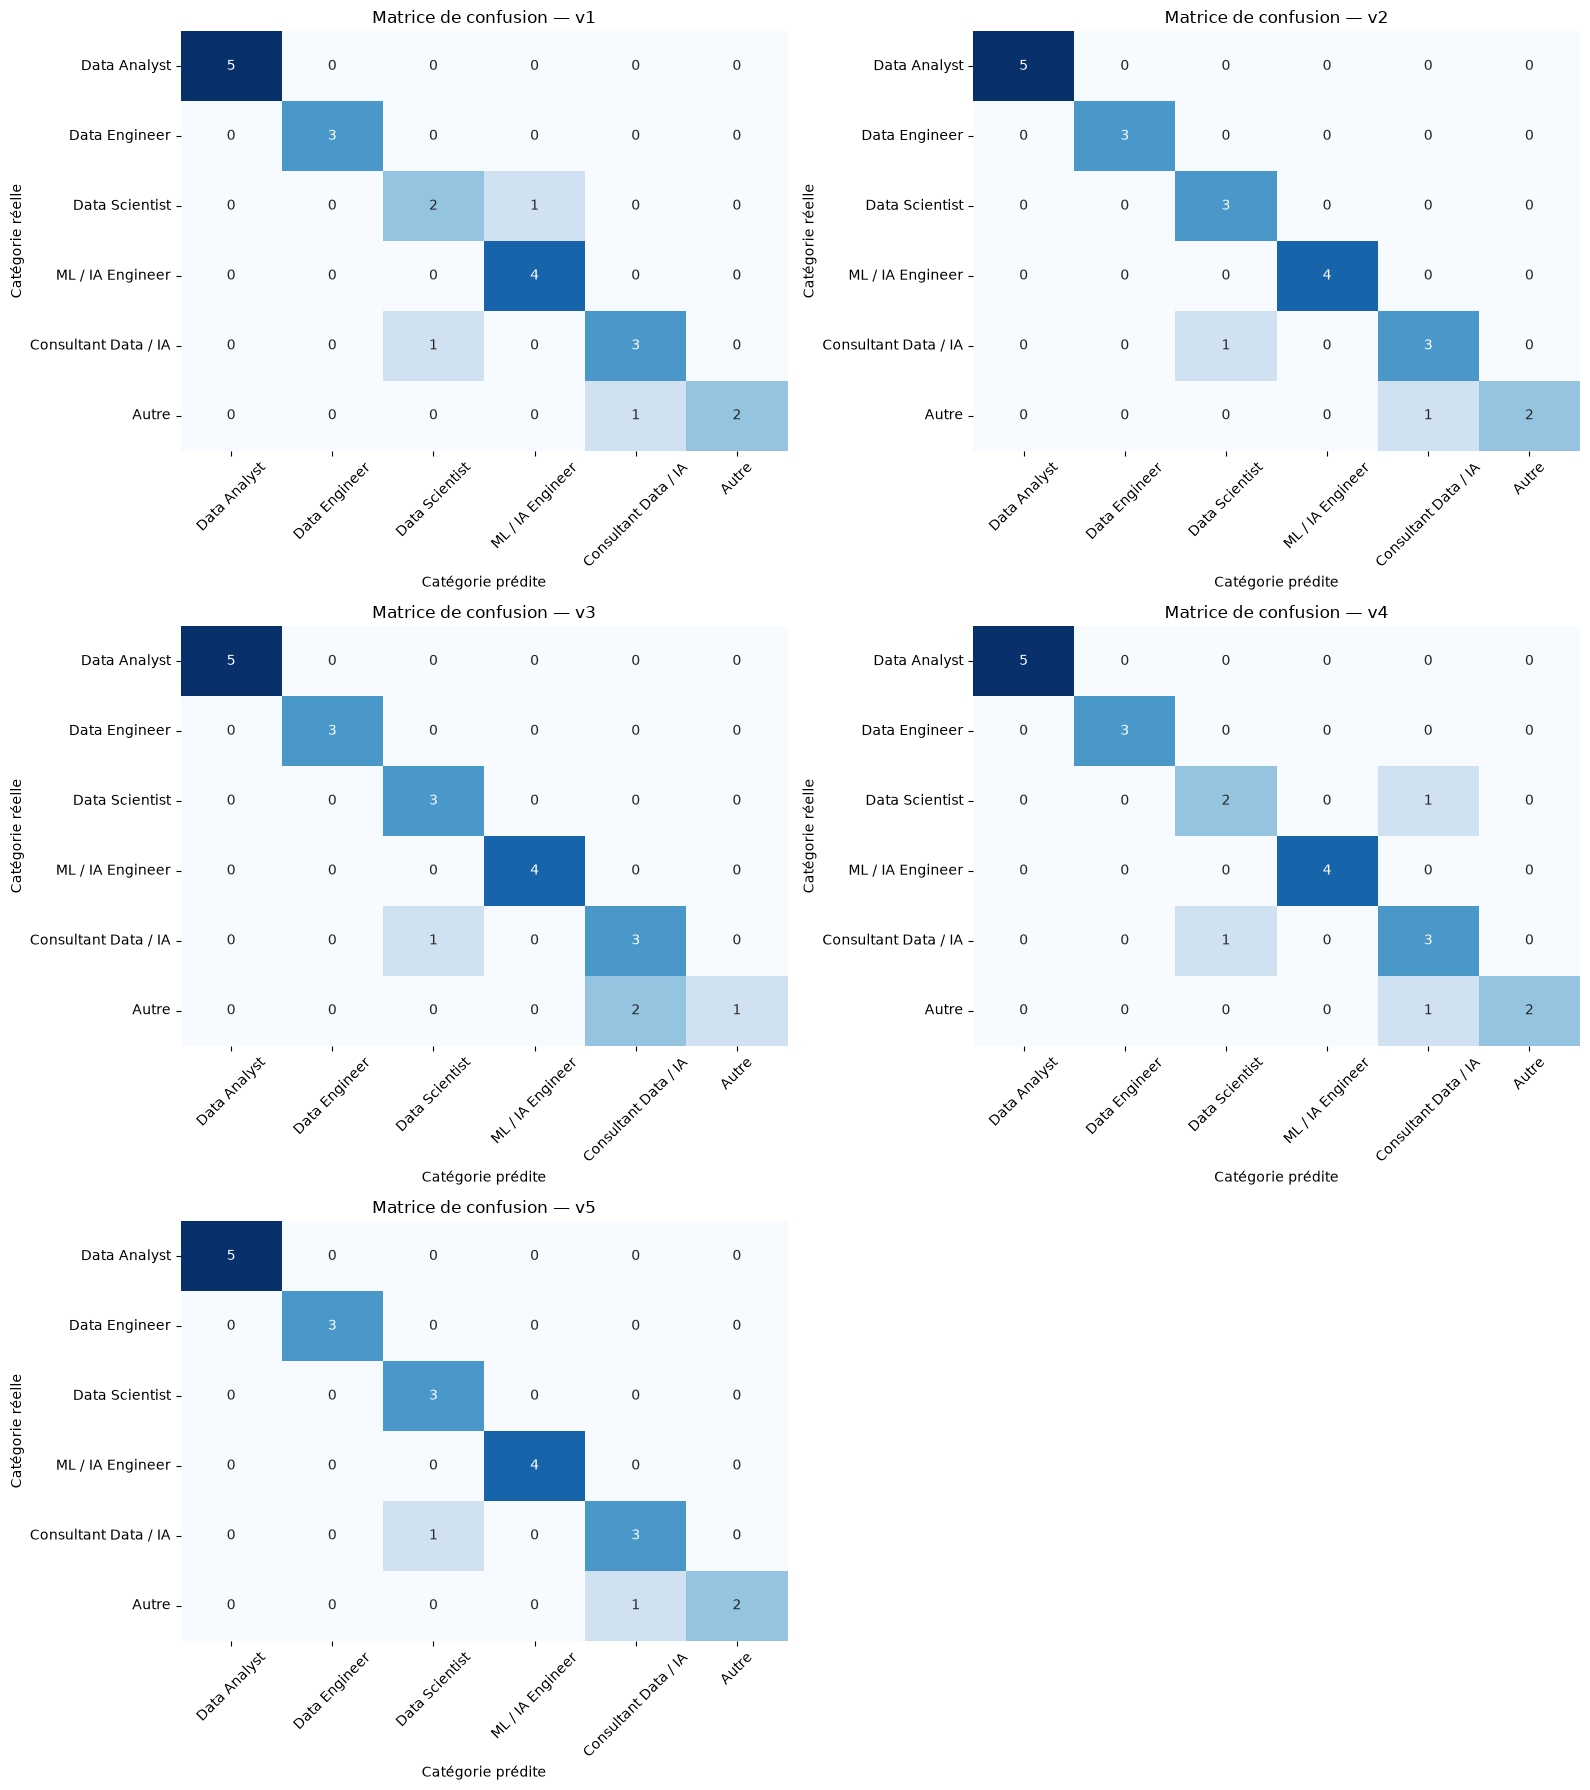


ERREURS — v1 : 3 offres


,entreprise,poste,Job_cat,cat_regex,pred_v1
2,Direct assurance,Data Scientist H/F,Data Scientist,Data Scientist,ML / IA Engineer
12,BCG X,"Forward Deployed AI Scientist, France - BCG X",Consultant Data / IA,ML / IA Engineer,Data Scientist
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA



ERREURS — v2 : 2 offres


,entreprise,poste,Job_cat,cat_regex,pred_v2
12,BCG X,"Forward Deployed AI Scientist, France - BCG X",Consultant Data / IA,ML / IA Engineer,Data Scientist
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA



ERREURS — v3 : 3 offres


...


ERREURS — v4 : 3 offres


,entreprise,poste,Job_cat,cat_regex,pred_v4
0,Groupe Crédit Agricole,ALTERNANCE - Analyste Marketing / Data Scienti...,Data Scientist,Data Scientist,Consultant Data / IA
12,BCG X,"Forward Deployed AI Scientist, France - BCG X",Consultant Data / IA,ML / IA Engineer,Data Scientist
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA



ERREURS — v5 : 2 offres


,entreprise,poste,Job_cat,cat_regex,pred_v5
12,BCG X,"Forward Deployed AI Scientist, France - BCG X",Consultant Data / IA,ML / IA Engineer,Data Scientist
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA


,version,nb_erreurs,taux_erreur
0,v2,2,0.090909
1,v5,2,0.090909
2,v3,3,0.136364
3,v1,3,0.136364
4,v4,3,0.136364


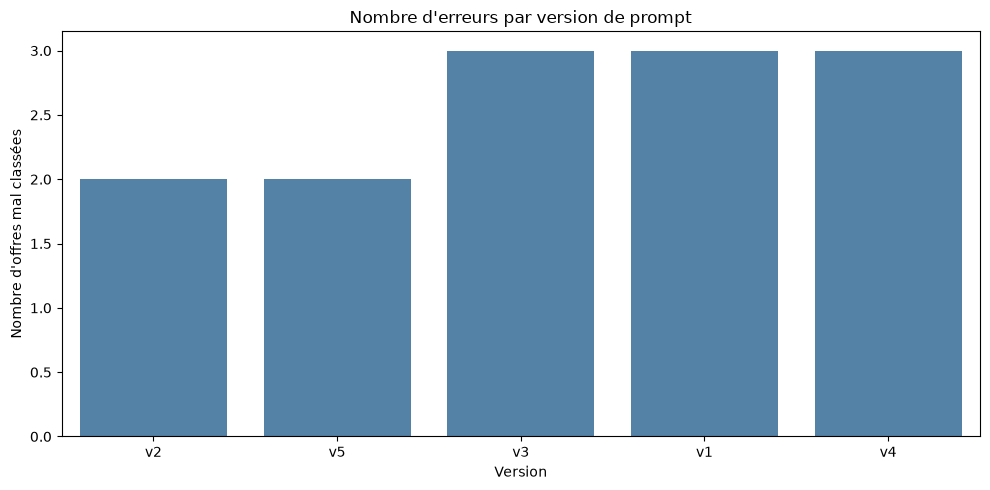


COMPARAISON DES PRÉDICTIONS PAR OFFRE


,entreprise,poste,Job_cat,cat_regex,pred_v1,pred_v2,pred_v3,pred_v4,pred_v5,nb_prompts_en_erreur
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,5
12,BCG X,"Forward Deployed AI Scientist, France - BCG X",Consultant Data / IA,ML / IA Engineer,Data Scientist,Data Scientist,Data Scientist,Data Scientist,Data Scientist,5
4,Coface,Product Owner / API Developer Experience Tools,Autre,Autre,Autre,Autre,Consultant Data / IA,Autre,Autre,1
2,Direct assurance,Data Scientist H/F,Data Scientist,Data Scientist,ML / IA Engineer,Data Scientist,Data Scientist,Data Scientist,Data Scientist,1
0,Groupe Crédit Agricole,ALTERNANCE - Analyste Marketing / Data Scienti...,Data Scientist,Data Scientist,Data Scientist,Data Scientist,Data Scientist,Consultant Data / IA,Data Scientist,1
1,CGI,Consultant Data Gouvernance - Secteur Public H/F,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,0
5,Lobellia,Chef de projet / Manager Data - Pilotage equip...,Consultant Data / IA,Data Analyst,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,0
3,PROPULSE IT,INGENIEUR DATA BI - GENIO,Data Engineer,Data Engineer,Data Engineer,Data Engineer,Data Engineer,Data Engineer,Data Engineer,0
6,Vusion,Chef de Projet IA H/F,Consultant Data / IA,Autre,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,0
7,Lucis (YC P25),AI engineering,ML / IA Engineer,ML / IA Engineer,ML / IA Engineer,ML / IA Engineer,ML / IA Engineer,ML / IA Engineer,ML / IA Engineer,0



CONFUSIONS LES PLUS FRÉQUENTES — v1


,Job_cat,pred_v1,nombre
0,Autre,Consultant Data / IA,1
1,Consultant Data / IA,Data Scientist,1
2,Data Scientist,ML / IA Engineer,1



CONFUSIONS LES PLUS FRÉQUENTES — v2


...


CONFUSIONS LES PLUS FRÉQUENTES — v4


,Job_cat,pred_v4,nombre
0,Autre,Consultant Data / IA,1
1,Consultant Data / IA,Data Scientist,1
2,Data Scientist,Consultant Data / IA,1



CONFUSIONS LES PLUS FRÉQUENTES — v5


,Job_cat,pred_v5,nombre
0,Autre,Consultant Data / IA,1
1,Consultant Data / IA,Data Scientist,1



Analyses exportées avec succès.


In [78]:
# ============================================================
# 4. Comparaison des prompts
# ============================================================

df_metrics = (
    pd.DataFrame(metrics)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("\nCOMPARAISON DES PROMPTS")
display(df_metrics)

import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# 5. Matrices de confusion de TOUTES les versions
# ============================================================

versions = list(prompts.keys())

n_cols = 2
n_rows = math.ceil(len(versions) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 6 * n_rows),
    squeeze=False
)

for i, version in enumerate(versions):

    ax = axes.flat[i]
    col_pred = f"pred_{version}"

    cm = confusion_matrix(
        resultats["Job_cat"],
        resultats[col_pred],
        labels=categories
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=categories,
        yticklabels=categories,
        ax=ax,
        cbar=False
    )

    ax.set_title(f"Matrice de confusion — {version}")
    ax.set_xlabel("Catégorie prédite")
    ax.set_ylabel("Catégorie réelle")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

# Supprimer les graphiques vides
for j in range(len(versions), len(axes.flat)):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.show()

# ============================================================
# 6. Erreurs de classification pour TOUTES les versions
# ============================================================

erreurs_par_version = {}
resume_erreurs = []

for version in versions:

    col_pred = f"pred_{version}"

    erreurs = resultats.loc[
        resultats["Job_cat"] != resultats[col_pred]
    ].copy()

    erreurs_par_version[version] = erreurs

    resume_erreurs.append({
        "version": version,
        "nb_erreurs": len(erreurs),
        "taux_erreur": len(erreurs) / len(resultats)
    })

    print(f"\n{'=' * 60}")
    print(f"ERREURS — {version} : {len(erreurs)} offres")
    print(f"{'=' * 60}")

    colonnes = [
        "entreprise",
        "poste",
        "Job_cat",
        "cat_regex",
        col_pred
    ]

    display(erreurs[
        [c for c in colonnes if c in erreurs.columns]
    ])

# ============================================================
# 7. Comparaison du nombre d'erreurs
# ============================================================

df_erreurs = (
    pd.DataFrame(resume_erreurs)
    .sort_values("nb_erreurs")
    .reset_index(drop=True)
)

display(df_erreurs)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_erreurs,
    x="version",
    y="nb_erreurs",
    color="steelblue"
)

plt.title("Nombre d'erreurs par version de prompt")
plt.xlabel("Version")
plt.ylabel("Nombre d'offres mal classées")
plt.tight_layout()
plt.show()

# ============================================================
# 8. Tableau des prédictions de toutes les versions
# ============================================================

colonnes_comparaison = [
    "entreprise",
    "poste",
    "Job_cat",
    "cat_regex"
] + [f"pred_{v}" for v in versions]

comparaison = resultats[
    [c for c in colonnes_comparaison if c in resultats.columns]
].copy()

# Nombre de prompts qui se trompent pour chaque offre
comparaison["nb_prompts_en_erreur"] = sum(
    comparaison[f"pred_{v}"] != comparaison["Job_cat"]
    for v in versions
)

# Offres les plus difficiles en premier
comparaison = comparaison.sort_values(
    "nb_prompts_en_erreur",
    ascending=False
)

print("\nCOMPARAISON DES PRÉDICTIONS PAR OFFRE")
display(comparaison)

# ============================================================
# 9. Confusions les plus fréquentes par version
# ============================================================

for version, erreurs in erreurs_par_version.items():

    col_pred = f"pred_{version}"

    confusions = (
        erreurs.groupby(["Job_cat", col_pred])
        .size()
        .reset_index(name="nombre")
        .sort_values("nombre", ascending=False)
    )

    print(f"\nCONFUSIONS LES PLUS FRÉQUENTES — {version}")
    display(confusions)

# ============================================================
# 10. Export des analyses
# ============================================================

output_dir = Path("src/extraction/data_llm/evaluation_prompts")
output_dir.mkdir(parents=True, exist_ok=True)

with pd.ExcelWriter(
    output_dir / "analyse_erreurs_prompts.xlsx"
) as writer:

    df_metrics.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

    comparaison.to_excel(
        writer,
        sheet_name="comparaison",
        index=False
    )

    for version, erreurs in erreurs_par_version.items():
        erreurs.to_excel(
            writer,
            sheet_name=f"erreurs_{version}"[:31],
            index=False
        )

fig.savefig(
    output_dir / "matrices_confusion.png",
    dpi=200,
    bbox_inches="tight"
)

print("\nAnalyses exportées avec succès.")
